In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Helper function to display images
def display_images(images, titles, cmap='gray', figsize=(14, 4)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(img, cmap=cmap)
        plt.title(title)
        plt.axis('off')
    plt.show()

### Read `CoffeeBeans.tif` and threshold it

In [23]:
img = cv2.imread('CoffeeBeans.tif')
img.shape
print("Image shape:", img.shape, "min/max:", img.min(), img.max())

Image shape: (296, 301, 3) min/max: 0 231


In [24]:
# Convert to grayscale (I was getting the error "'src_type' is 64 (CV_8UC3)")
if img.ndim == 3:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
# Convert to 8-bit before applying Otsu

img_8bit = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) if (img.dtype != np.uint8) else img

In [26]:
# Otsu with 0 threshold
threshold_value, binary = cv2.threshold(
    img_8bit, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
print("Otsu threshold: ", threshold_value)
print("Binary: ", binary)

Otsu threshold:  71.0
Binary:  [[  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 ...
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]
 [  0   0   0 ... 255 255 255]]


In [27]:
if np.mean(binary) > 127:
    True

Text(0.5, 1.0, 'Original Image')

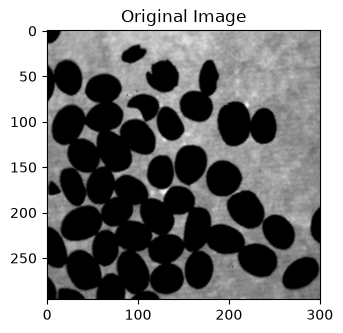

In [28]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img_8bit, cmap='gray')
plt.title("Original Image")

Text(0.5, 1.0, 'Otsu binary')

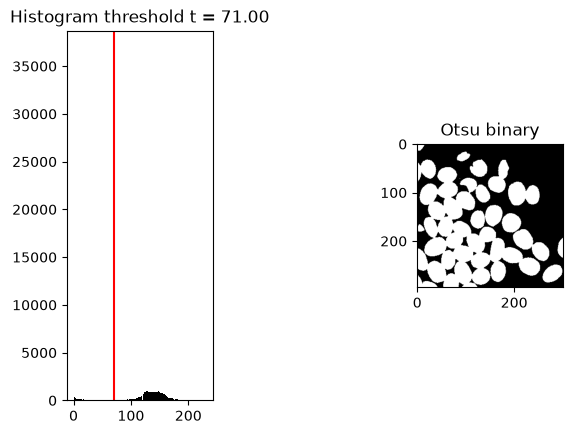

In [29]:
plt.subplot(1,3, 1)
plt.hist(img_8bit.ravel(), bins=256, color='k')
plt.title('Histogram threshold t = {:.2f}'.format(threshold_value))
plt.axvline(threshold_value, color='r')

t, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Beans are WHITE (foreground). Invert if they're black.
if np.mean(binary) > 127:
    binary = cv2.bitwise_not(binary)

plt.subplot(1,3,3)
plt.imshow(binary, cmap='gray')
plt.title("Otsu binary")


 ## Segment and label each coffee bean

Here is my approach -
```text
Raw image
   ↓
1. Grayscale + Otsu (binary mask) ➡ done above
   ↓
2. Morphological cleanup (remove specks, fill holes)
   ↓
3. Separate touching beans:
      Distance transform → local maxima → watershed
   ↓
4. Label each bean
   ↓
5. Filter tiny regions, measure area/centroid, overlay
```

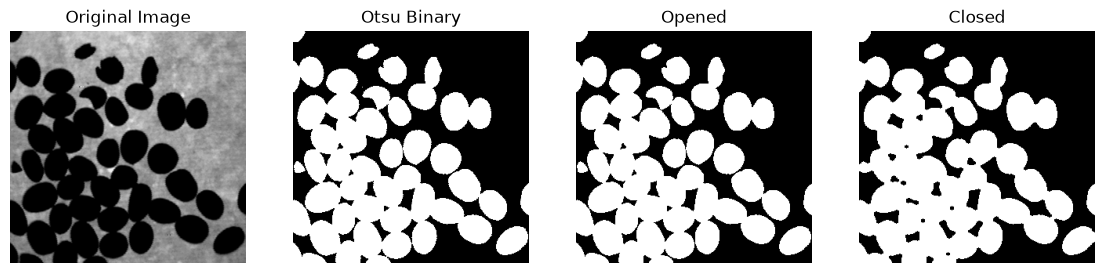

In [30]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))

opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

display_images([img_8bit, binary, opened, closed],
               ["Original Image", "Otsu Binary", "Opened", "Closed"])

- Distance transform — for every foreground pixel, distance to nearest background pixel. The center of a bean has a large value; the boundary near where two beans touch has a small value.

- Find local maxima of the distance map → these are the bean centers (candidate seeds).

- Markers = label each seed with a unique integer, background as 0.

- Watershed floods from the seeds and carves boundaries where floods meet.

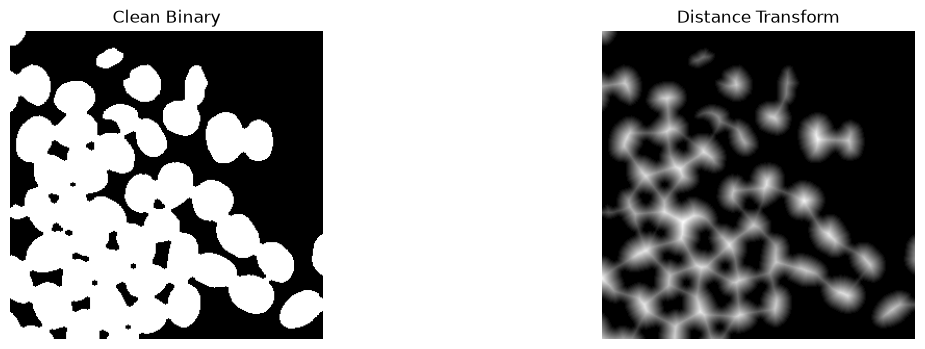

In [31]:
# Distance transform
dist_transform = cv2.distanceTransform(closed, cv2.DIST_L2, 5)
dist_transform = cv2.normalize(
    dist_transform, None, 0, 1.0, cv2.NORM_MINMAX).astype(np.float32)
display_images([closed, dist_transform], ["Clean Binary", "Distance Transform"])


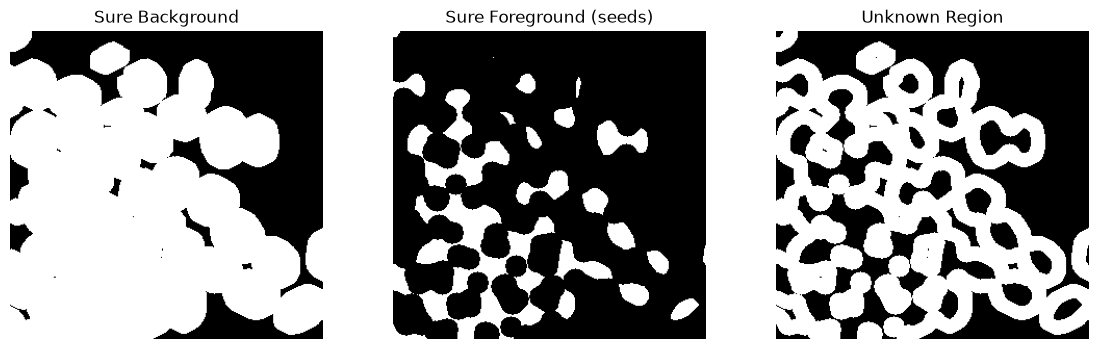

In [32]:
# Threshold the distance transform to get the sure foreground, get the blobs
_, sure_fg = cv2.threshold(dist_transform, 0.4 * dist_transform.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

# Background
sure_bg = cv2.dilate(closed, kernel, iterations=3)

# Unknown region between foreground and background
unknown = cv2.subtract(sure_bg, sure_fg)

display_images([sure_bg, sure_fg, unknown], ["Sure Background", "Sure Foreground (seeds)", "Unknown Region"])

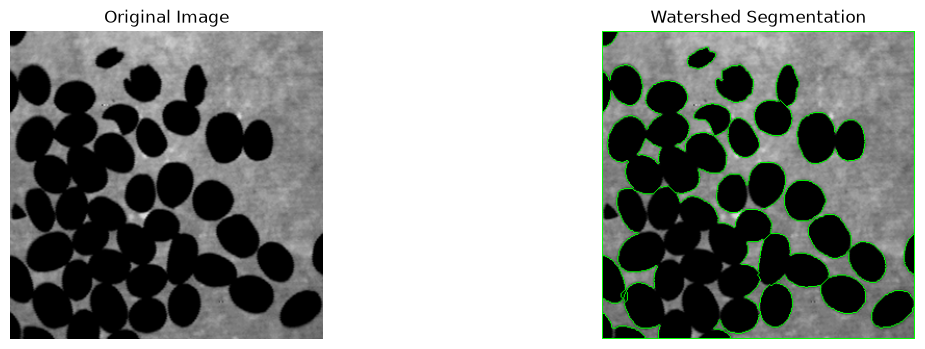

In [33]:
# Label each seeds 
n_seeds, markers = cv2.connectedComponents(sure_fg)

# Watershed requires markers to be 1-based, so add 1 to all labels, unknown region = 0
markers = markers + 1
markers[unknown == 255] = 0

# Watershed needs a 3-channel image as input (it operates on color gradients)
img_bgr = cv2.cvtColor(img_8bit, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_bgr, markers)

# Mark boundaries in green
overlay = img_bgr.copy()
overlay[markers == -1] = (0,255,0)

display_images([img_bgr, overlay], ["Original Image", "Watershed Segmentation"])

##### Label each Bean

In [34]:
labels = [l for l in np.unique(markers) if l > 0]
print(f"Detected {len(labels)} regions")

results = []
MIN_AREA = 50
for l in labels:
    mask = (markers == l)
    area = int(mask.sum())
    if area < MIN_AREA:
        continue
    ys, xs = np.where(mask)
    cx, cy = float(xs.mean()), float(ys.mean())
    results.append((l, area, cx, cy))

print(f"{len(results)} beans after area filtering")

Detected 25 regions
23 beans after area filtering


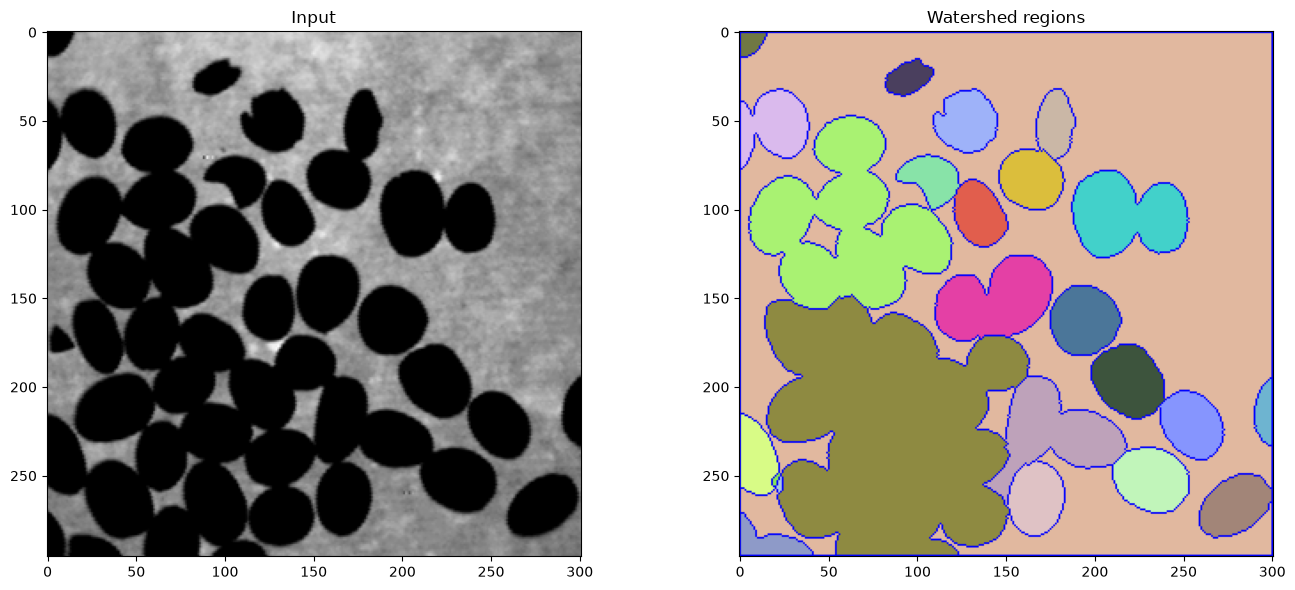

In [35]:
# Color each watershed region
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
rng = np.random.default_rng(0)
for l in [l for l in np.unique(markers) if l > 0]:
    color = tuple(int(c) for c in rng.integers(60, 255, 3))
    output[markers == l] = color
output[markers == -1] = (0, 0, 255)   

plt.figure(figsize=(14, 6))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')    
plt.title("Input")

plt.subplot(1,2,2)
plt.imshow(output)
plt.title("Watershed regions")
plt.tight_layout()

### Count Beans and calculate area of each

In [36]:
# See all the markers and their areas
all_regions = [(l, int((markers == l).sum())) for l in np.unique(markers) if l > 0]
all_regions.sort(key=lambda x: x[1])

print("All region areas (sorted):")
for l, a in all_regions:
    flag = "  ← DROPPED" if a < 50 else ""
    print(f"  label {l:3d}  area {a:6d}{flag}")

All region areas (sorted):
  label  22  area     14  ← DROPPED
  label  23  area     17  ← DROPPED
  label   2  area    136
  label  17  area    251
  label   3  area    338
  label  25  area    432
  label   6  area    600
  label   9  area    619
  label  19  area    704
  label  11  area    789
  label   5  area    898
  label   8  area    938
  label  18  area    988
  label  21  area    996
  label  24  area   1002
  label   4  area   1102
  label  13  area   1160
  label  20  area   1184
  label  15  area   1232
  label  12  area   2167
  label  10  area   2262
  label  16  area   2348
  label   7  area   6602
  label  14  area  15485
  label   1  area  42615


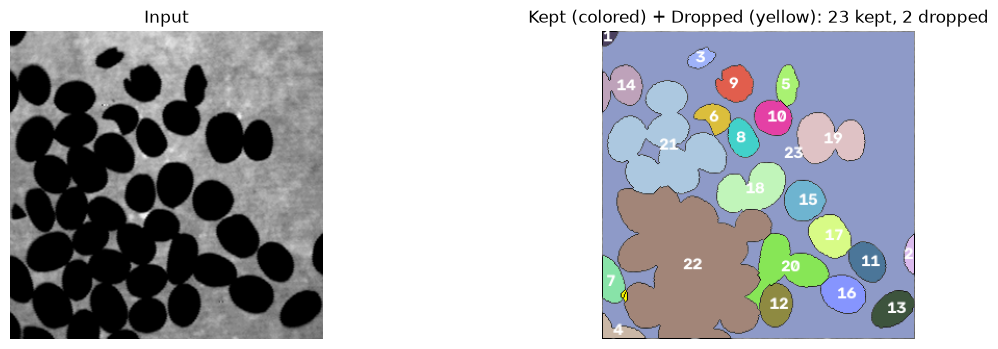

In [37]:
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
rng = np.random.default_rng(0)

kept, dropped = [], []
for l, a in all_regions:
    color = tuple(int(c) for c in rng.integers(60, 255, 3))
    if a >= 50:
        output[markers == l] = color
        kept.append(l)
    else:
        output[markers == l] = (255, 255, 0)   # yellow = dropped
        dropped.append(l)

# Draw centroids and index for each KEPT bean
for i, l in enumerate(kept):
    ys, xs = np.where(markers == l)
    cx, cy = int(xs.mean()), int(ys.mean())
    cv2.putText(output, str(i+1), (cx-5, cy+5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)

display_images([img, output],
     titles=["Input", f"Kept (colored) + Dropped (yellow): {len(kept)} kept, {len(dropped)} dropped"])

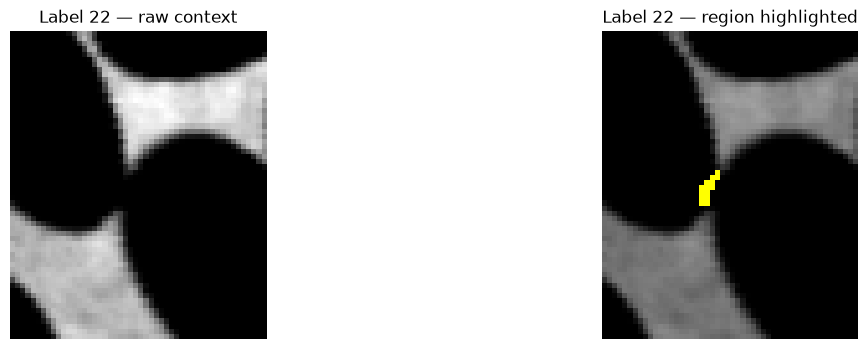

Label 22: area=14, center=(20,252)


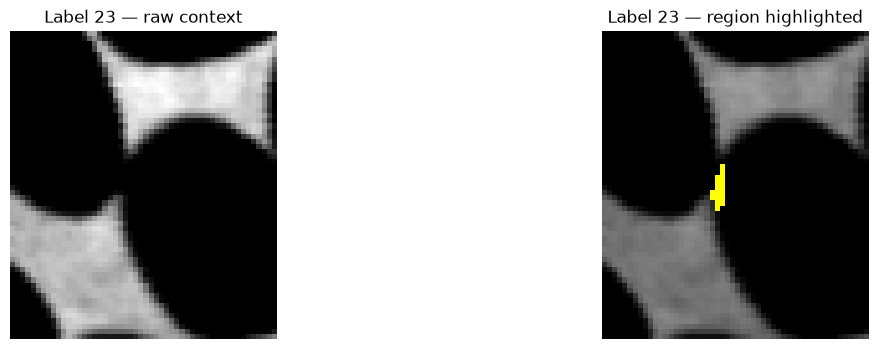

Label 23: area=17, center=(22,255)


In [45]:
# What's going on with the dropped regions?
for l in [22, 23]:   # dropped labels
    ys, xs = np.where(markers == l)
    cy, cx = int(ys.mean()), int(xs.mean())
    
    # A 30-pixel padding window around the region
    pad = 30
    y0, y1 = max(0, cy-pad), min(img.shape[0], cy+pad)
    x0, x1 = max(0, cx-pad), min(img.shape[1], cx+pad)
    crop = img[y0:y1, x0:x1].copy()
    mask_crop = (markers[y0:y1, x0:x1] == l)
    
    crop_color = cv2.cvtColor(crop, cv2.COLOR_GRAY2BGR)
    crop_color[mask_crop] = (255, 255, 0)
    
    display_images([crop, crop_color], [f"Label {l} — raw context", f"Label {l} — region highlighted"])
    
    print(f"Label {l}: area={mask_crop.sum()}, center=({cx},{cy})")

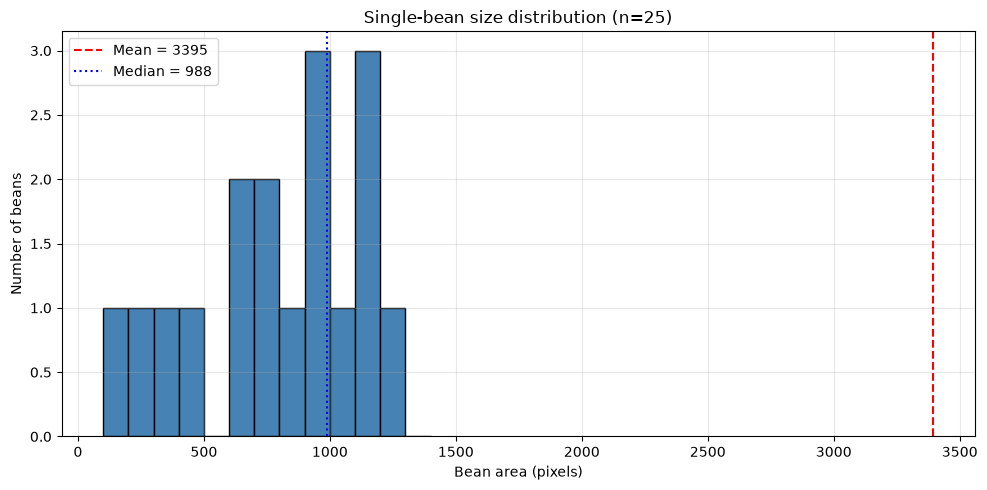

In [39]:
# Bean Histogram upto range mean

plt.figure(figsize=(10, 5))
plt.hist([a for l, a in all_regions], bins=np.arange(100, 1500, 100),   # integer-width bins
         edgecolor='black', color='steelblue')
plt.axvline(np.array([a for l, a in all_regions]).mean(),   color='red',  linestyle='--',
            label=f"Mean = {np.array([a for l, a in all_regions]).mean():.0f}")
plt.axvline(np.median(np.array([a for l, a in all_regions])), color='blue', linestyle=':',
            label=f"Median = {np.median(np.array([a for l, a in all_regions])):.0f}")
plt.xlabel("Bean area (pixels)")
plt.ylabel("Number of beans")
plt.title(f"Single-bean size distribution (n={len(all_regions)})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


Range: 14 to 42615


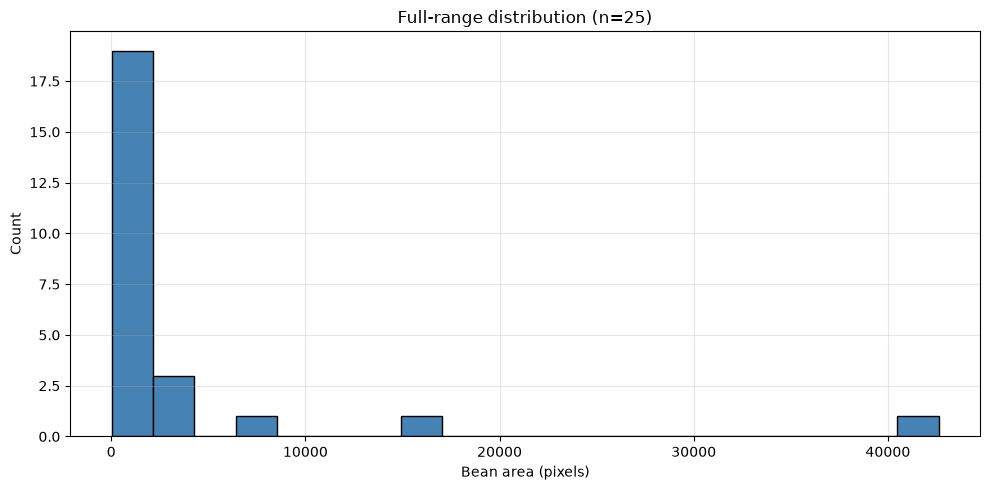

In [40]:
# Full range histogram
print("Range:", all_regions[0][1], "to", all_regions[-1][1])

plt.figure(figsize=(10, 5))
plt.hist([a for l, a in all_regions], bins=20, edgecolor='black', color='steelblue')
plt.xlabel("Bean area (pixels)")
plt.ylabel("Count")
plt.title(f"Full-range distribution (n={len(all_regions)})")
plt.grid(alpha=0.3)
plt.tight_layout()